Лабораториска вежба бр.4
--
Адаптивни бази фунциски модели

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)
from sklearn.neural_network import MLPClassifier

In [5]:
columns=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df=pd.read_csv('car.data', header=None, names=columns)

In [6]:
print(f"Број на примери: {len(df)}")
print(f"Број на атрибути: {len(df.columns)-1}")
print()
df.head()

Број на примери: 1728
Број на атрибути: 6



,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


Нема missing values

In [9]:
df['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


Датасетот е нерамномерен

Претппроцесирање
--

In [10]:
print(df.columns)

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')


In [11]:
for c in columns:
  print(c)
  print(df[c].unique())

buying
['vhigh' 'high' 'med' 'low']
maint
['vhigh' 'high' 'med' 'low']
doors
['2' '3' '4' '5more']
persons
['2' '4' 'more']
lug_boot
['small' 'med' 'big']
safety
['low' 'med' 'high']
class
['unacc' 'acc' 'vgood' 'good']


Тука е најдобро да се искористи Oridnal Encoder бидејќи има некаква природна подреденост кај атрибутите.

In [12]:
buying_order   = ['low', 'med', 'high', 'vhigh']
maint_order    = ['low', 'med', 'high', 'vhigh']
doors_order    = ['2', '3', '4', '5more']
persons_order  = ['2', '4', 'more']
lug_order      = ['small', 'med', 'big']
safety_order   = ['low', 'med', 'high']

enc_ord = OrdinalEncoder(categories=[buying_order, maint_order, doors_order, persons_order, lug_order, safety_order])

X_ordinal = enc_ord.fit_transform(df[columns[:-1]])

In [13]:
print(f" Пример без енкодирање: {df.iloc[0, :-1].values}")
print(f" Пример со енкодирање:  {X_ordinal[0]}")
print()

 Пример без енкодирање: ['vhigh' 'vhigh' '2' '2' 'small' 'low']
 Пример со енкодирање:  [3. 3. 0. 0. 0. 0.]



In [14]:
df['class'].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

За целната класа користиме Label Encoder

In [15]:
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(df['class'])

Поделба на train и test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ordinal, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} примери")
print(f"Test:  {X_test.shape[0]} примери")

Train: 1382 примери
Test:  346 примери


# **Decision Tree**

### Главни параметри:
- `max_depth` — максимална длабочина (контролира overfitting)
- `min_samples_split` — минимум примери за да се направи сплит
- `min_samples_leaf` — минимум примери во лист
- `criterion` — `'gini'` или `'entropy'`


In [17]:
# PARAMETAR max_depth
#---------------------------
# kontrolira kolku dlaboko moze da raste drvoto
# pomala dlabocina znaci modelot e poednostaven i ima pomalku rizik od overfitting
# pogolema dlabocina znaci modelot e pokolmpleksen

depths=[2,3,4,5,6,7,None]
results_depth=[]

for d in depths:
  clf=DecisionTreeClassifier(max_depth=d, random_state=42)
  clf.fit(X_train, y_train)
  acc_train=accuracy_score(y_train, clf.predict(X_train))
  acc_test=accuracy_score(y_test, clf.predict(X_test))
  results_depth.append({
      'max_depth': str(d),
      'Train Accuracy': acc_train,
      'Test Accuracy': acc_test,
      'Leaves': clf.get_n_leaves(),
      'Depth': clf.get_depth()
  })
  print(f'depth={str(d):5s} | Train={acc_train: .4f} | Test={acc_test: .4f} | Leaves={clf.get_n_leaves()}')

df_depth=pd.DataFrame(results_depth)

depth=2     | Train= 0.7771 | Test= 0.7803 | Leaves=3
depth=3     | Train= 0.7887 | Test= 0.8035 | Leaves=4
depth=4     | Train= 0.8517 | Test= 0.8468 | Leaves=6
depth=5     | Train= 0.8777 | Test= 0.8699 | Leaves=10
depth=6     | Train= 0.9320 | Test= 0.9451 | Leaves=17
depth=7     | Train= 0.9385 | Test= 0.9364 | Leaves=28
depth=None  | Train= 1.0000 | Test= 0.9913 | Leaves=81


Како што се зголемува depth, така accuracy расте. Тоа значи дека дрвото учи посложени правила. Може да се заклучи дека depth=6 е оптимален и тука test accuracy е највисок (0.9451). За depth=7  веќе може да се види дека тука има знакк на Overfitting бидејќи дава полош Test резултат иако Train е поголем.

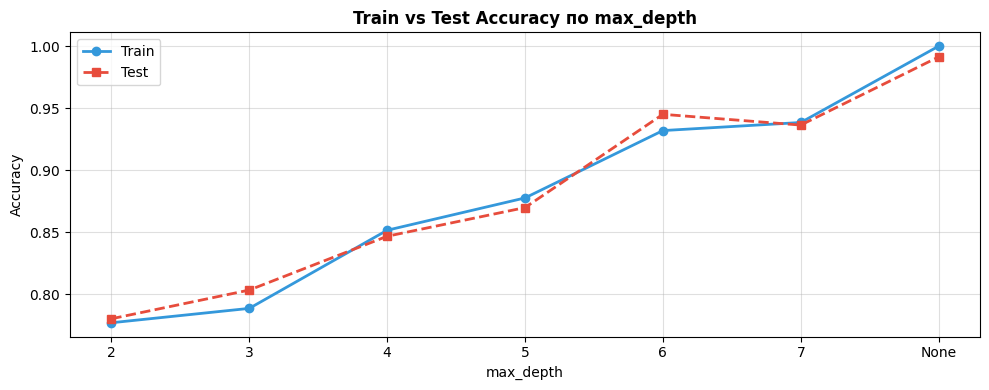

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Train vs Test Accuracy
ax.plot(df_depth['max_depth'], df_depth['Train Accuracy'], 'o-', color='#3498db', lw=2, label='Train')
ax.plot(df_depth['max_depth'], df_depth['Test Accuracy'], 's--', color='#e74c3c', lw=2, label='Test')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy по max_depth', fontweight='bold')
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


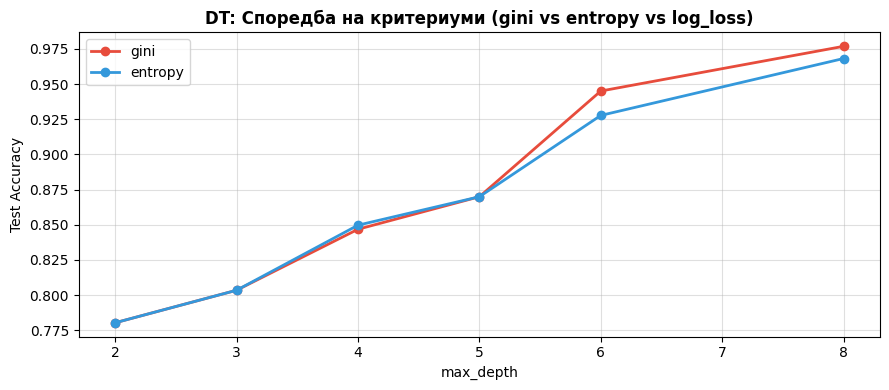

In [19]:
# PARAMETAR criterion
criterions = ['gini', 'entropy']
fig, ax = plt.subplots(figsize=(9, 4))

for crit, color in zip(criterions, ['#e74c3c', '#3498db']):
    accs = []
    for d in [2, 3, 4, 5, 6, 8]:
        clf = DecisionTreeClassifier(max_depth=d, criterion=crit, random_state=42)
        clf.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, clf.predict(X_test)))
    ax.plot([2, 3, 4, 5, 6, 8], accs, 'o-', label=crit, color=color, lw=2)

ax.set_xlabel('max_depth'); ax.set_ylabel('Test Accuracy')
ax.set_title('DT: Споредба на критериуми (gini vs entropy vs log_loss)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


**Gini** - мери колку е нечиста групата по сплитот. На пример ако има група каде има 100% од една класа тогаш gini=0.

**Entropy** - мери колку неизвесност има во групата и се пресметува со логаритам.

Што може да заклучиме?
--
*   Двете линии се скоро идентични
*   Gini е малку над Entropy за depth=6,7,8
*   И двата критериуми го достигнуваат оптимумот кај depth=6



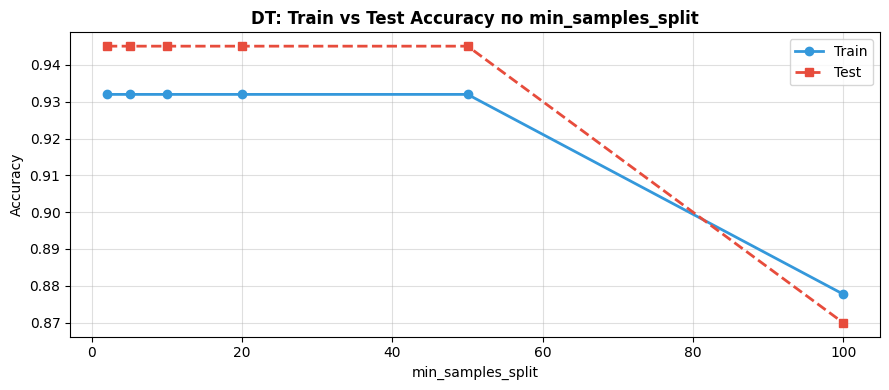

In [20]:
# PARAMETAR min_samples_split
#-------------------------------------------
# min_samples_split e minimalen broj an primeri sto eden jazol mora da gi ima za da se splitne

min_splits = [2, 5, 10, 20, 50, 100]
fig, ax = plt.subplots(figsize=(9, 4))

accs_train = []
accs_test = []

for ms in min_splits:
    clf = DecisionTreeClassifier(max_depth=6, criterion='gini', min_samples_split=ms, random_state=42)
    clf.fit(X_train, y_train)
    accs_train.append(accuracy_score(y_train, clf.predict(X_train)))
    accs_test.append(accuracy_score(y_test, clf.predict(X_test)))

ax.plot(min_splits, accs_train, 'o-', color='#3498db', lw=2, label='Train')
ax.plot(min_splits, accs_test, 's--', color='#e74c3c', lw=2, label='Test')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('Accuracy')
ax.set_title('DT: Train vs Test Accuracy по min_samples_split', fontweight='bold')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Во овој случај важно е да не го поставиме min_samples_split многу високо (>50) бидејќи тогаш дрвото станува многу едноставно и accuracy се намалува.  

In [21]:
# IDEALNO DECISION TREE
#------------------------------------

best_dt = DecisionTreeClassifier(
    max_depth=6,
    criterion='entropy',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)

print("Најдобар Decision Tree — параметри:")
print(f"  max_depth={best_dt.max_depth}, criterion='{best_dt.criterion}'")
print(f"  min_samples_split={best_dt.min_samples_split}")
print(f"  Вкупно листови: {best_dt.get_n_leaves()}")
print(f"  Реална длабочина: {best_dt.get_depth()}")
print()
print("Класификациски извештај:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))


Најдобар Decision Tree — параметри:
  max_depth=6, criterion='entropy'
  min_samples_split=5
  Вкупно листови: 15
  Реална длабочина: 6

Класификациски извештај:
              precision    recall  f1-score   support

         acc       0.86      0.81      0.83        77
        good       0.70      1.00      0.82        14
       unacc       0.97      0.98      0.97       242
       vgood       0.90      0.69      0.78        13

    accuracy                           0.93       346
   macro avg       0.86      0.87      0.85       346
weighted avg       0.93      0.93      0.93       346





*   precision - колку навистина се точни
*   recall - колку пропуштил
* f1-score - баланс меѓу precision i recall



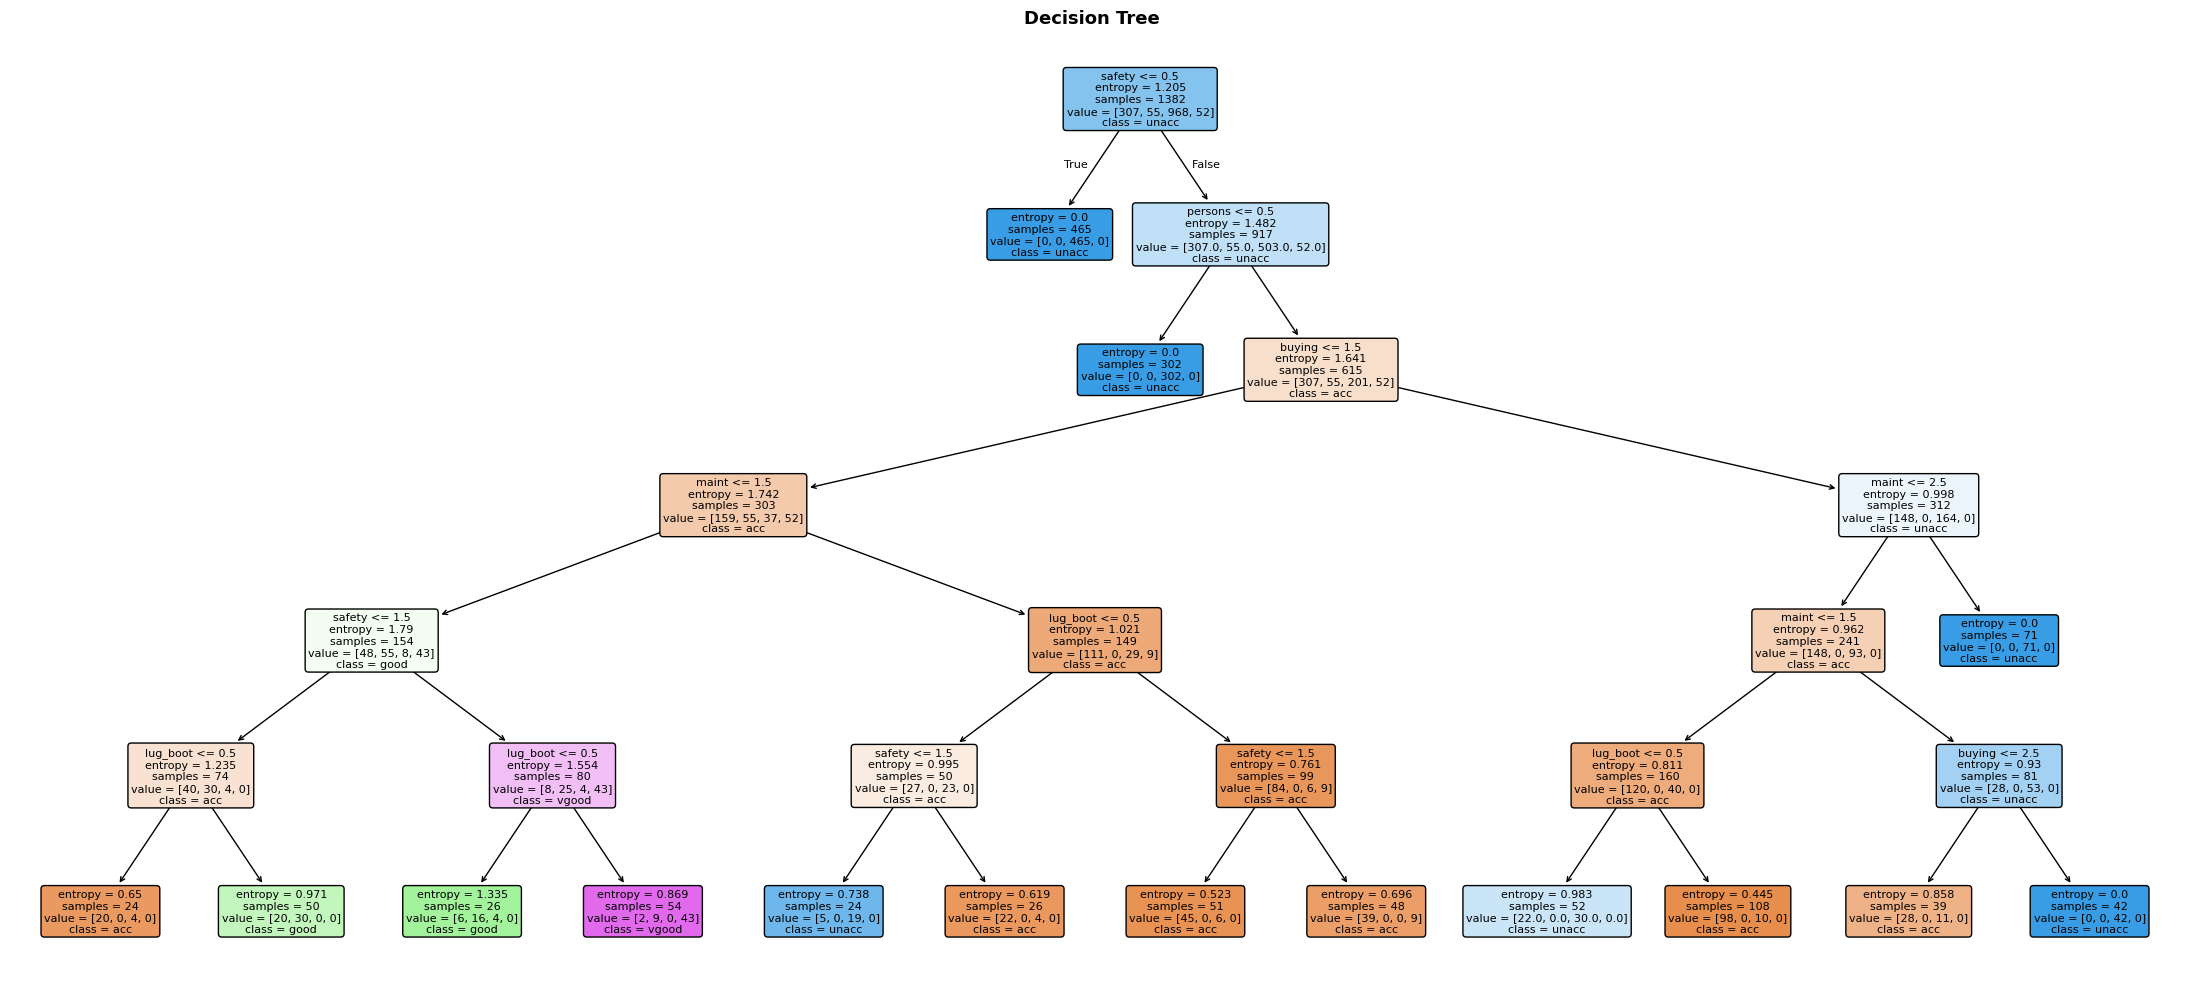

Бојата на јазлите ја покажува доминантната класа:
  Портокалова = unacc, Сина = acc, Зелена = good, Виолетова = vgood


In [22]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=columns[:-1],
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    max_depth=6
)
ax.set_title('Decision Tree ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Бојата на јазлите ја покажува доминантната класа:")
print("  Портокалова = unacc, Сина = acc, Зелена = good, Виолетова = vgood")


In [23]:
# ── ВАЖНОСТ НА АТРИБУТИТЕ ────────────────────────────────────────────
# Feature importance = кој атрибут најмногу ја намалува ентропијата
feature_names = ["feat1", "feat2", "feat3", "feat4", "feat5", "feat6"]
fi_dt = pd.Series(best_dt.feature_importances_, index=feature_names)
print("Важност на атрибутите :")
for feat, imp in fi_dt.sort_values(ascending=False).items():
    print(f"  {feat:12s}: {imp:.4f} ({imp*100:.1f}% важност)")

Важност на атрибутите :
  feat6       : 0.3075 (30.7% важност)
  feat4       : 0.2707 (27.1% важност)
  feat1       : 0.1636 (16.4% важност)
  feat2       : 0.1595 (16.0% важност)
  feat5       : 0.0987 (9.9% важност)
  feat3       : 0.0000 (0.0% важност)


## Random Forest

### Главни параметри:
- `n_estimators` — Број на дрвја
- `max_features` —
- `bootstrap` — дали да се користи или не
- `max_depth` — максимална длабочина на секое дрво


  n_estimators=  5  →  Test Accuracy=0.9653
  n_estimators= 10  →  Test Accuracy=0.9711
  n_estimators= 25  →  Test Accuracy=0.9827
  n_estimators= 50  →  Test Accuracy=0.9855
  n_estimators=100  →  Test Accuracy=0.9855
  n_estimators=200  →  Test Accuracy=0.9884
  n_estimators=300  →  Test Accuracy=0.9884


/tmp/ipykernel_4401/2944388653.py:16: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(df_rf_n['n_estimators'], df_rf_n['Accuracy'], 'o-',


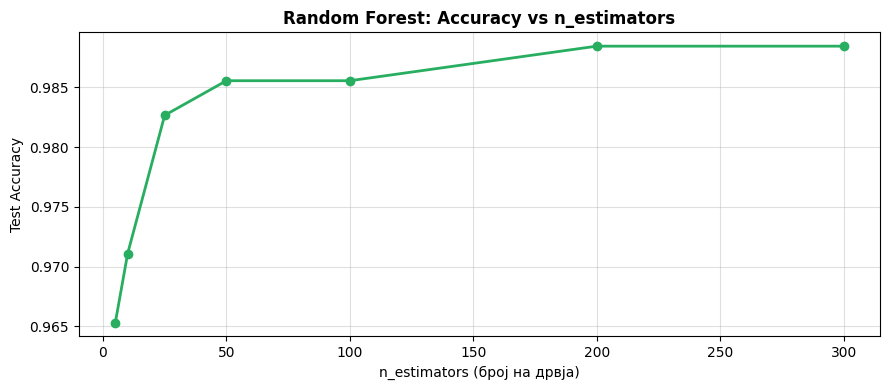

In [24]:
# PARAMETAR n_estimators

ns = [5, 10, 25, 50, 100, 200, 300]
rf_n_results = []

for n in ns:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    rf_n_results.append({'n_estimators': n, 'Accuracy': acc})
    print(f"  n_estimators={n:3d}  →  Test Accuracy={acc:.4f}")

df_rf_n = pd.DataFrame(rf_n_results)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_rf_n['n_estimators'], df_rf_n['Accuracy'], 'o-',
        color='#27ae60', lw=2, marker='o')
ax.set_xlabel('n_estimators (број на дрвја)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest: Accuracy vs n_estimators', fontweight='bold')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Оптимален избор е n=200, после тоа точноста не се подобрува.

  max_features=sqrt    →  Test Accuracy=0.9855
  max_features=log2    →  Test Accuracy=0.9855
  max_features=None    →  Test Accuracy=0.9971
  max_features=1       →  Test Accuracy=0.9740
  max_features=2       →  Test Accuracy=0.9855
  max_features=3       →  Test Accuracy=0.9884
  max_features=4       →  Test Accuracy=0.9913


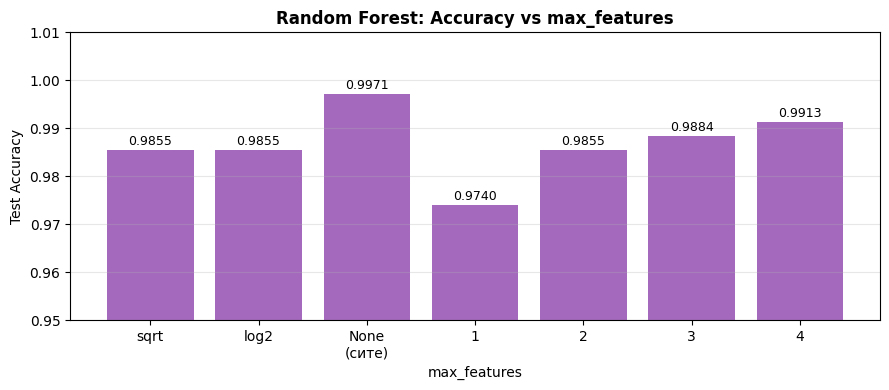

In [25]:
# PARAMETAR max_features
#-------------------------------------------------------------------------------
# kontrolira kolku atributi se razgleduvaat pri sekoj split
# sqrt = sqrt(6), 2-3 atributi
# log2 = log2(6), 2-3 atributi
# None = site 6 atributi

mf_opts   = ['sqrt', 'log2', None, 1, 2, 3, 4]
mf_labels = ['sqrt', 'log2', 'None\n(сите)', '1', '2', '3', '4']
mf_accs = []

for mf in mf_opts:
    rf = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    mf_accs.append(acc)
    print(f"  max_features={str(mf):6s}  →  Test Accuracy={acc:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(mf_labels, mf_accs, color='#8e44ad', alpha=0.8)
ax.set_xlabel('max_features'); ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest: Accuracy vs max_features', fontweight='bold')
ax.set_ylim(0.95, 1.01); ax.grid(alpha=0.3, axis='y')
for i, a in enumerate(mf_accs):
    ax.text(i, a + 0.001, f'{a:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


Доколку секое дрво ги гледа сите атрибути се прават најдобри сплитови, но дрвјата стануваат многу слични едни на други.

In [26]:
# ПАРАМЕТАР: bootstrap
# ─────────────────────────────────────────────
# Bootstrap = за секое дрво се зема случајно подмножество од тренинг податоците СО ЗАМЕНА
# Секое дрво гледа различни примери → разновидност → подобар ансамбл
# Bootstrap = True, ima zamena sekoe drvo gleda razlicen slucaen set, no moze nekoj da se povtori
# Bootstrap = False , nema zamena, sekoe drvo go gleda istiot slucaen set

for boot in [True, False]:
    rf = RandomForestClassifier(n_estimators=100, bootstrap=boot, random_state=42)
    rf.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, rf.predict(X_train))
    acc_te = accuracy_score(y_test, rf.predict(X_test))
    print(f"bootstrap={str(boot):5s}  Train={acc_tr:.4f}  Test={acc_te:.4f}")



bootstrap=True   Train=1.0000  Test=0.9855
bootstrap=False  Train=1.0000  Test=0.9827


In [27]:
# Idealen Random Forest
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

print("Најдобар Random Forest — класификациски извештај:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Најдобар Random Forest — класификациски извештај:
              precision    recall  f1-score   support

         acc       0.96      1.00      0.98        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.77      0.87        13

    accuracy                           0.99       346
   macro avg       0.97      0.94      0.95       346
weighted avg       0.99      0.99      0.99       346



## Neural Networks

In [28]:
# BROJ NA SKRIENI SLOEVI

architectures = {
    '1 слој (64)': (64,),
    '2 слоја (128,64)': (128, 64),
    '3 слоја (128,64,32)': (128, 64, 32),
    '4 слоја (256,128,64,32)': (256, 128, 64, 32)
}

for name, layers in architectures.items():
    nn = MLPClassifier(hidden_layer_sizes=layers, max_iter=500, random_state=42)
    nn.fit(X_train, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test))
    print(f"{name:30s} → Accuracy={acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


1 слој (64)                    → Accuracy=0.9653
2 слоја (128,64)               → Accuracy=0.9913
3 слоја (128,64,32)            → Accuracy=0.9971
4 слоја (256,128,64,32)        → Accuracy=0.9942


In [29]:
# AKTIVACISKI FUNKCII
# aktivaciskite funkcii vnesuvaat nelinearnost
# relu = (0,x)
# tanh = (-1,1)
# logistic/sigmoid = (0,1)

for act in ['relu', 'tanh', 'logistic']:
    nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation=act,
                       max_iter=500, random_state=42)
    nn.fit(X_train, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test))
    print(f"activation={act:10s} → Accuracy={acc:.4f}")

activation=relu       → Accuracy=0.9971
activation=tanh       → Accuracy=1.0000
activation=logistic   → Accuracy=0.9509


In [30]:
# STAPKKA NA UCENJE
# kolku golem cekor pravime pri sekoie azuriranje na tezinite

for lr in [0.0001, 0.001, 0.005, 0.01, 0.05]:
    nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32), learning_rate_init=lr,
                       max_iter=500, random_state=42)
    nn.fit(X_train, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test))
    print(f"learning_rate={lr:.4f} → Accuracy={acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


learning_rate=0.0001 → Accuracy=0.9682
learning_rate=0.0010 → Accuracy=0.9971
learning_rate=0.0050 → Accuracy=0.9971
learning_rate=0.0100 → Accuracy=0.9798
learning_rate=0.0500 → Accuracy=0.9335


In [34]:
# ── 4. ФИНАЛЕН МОДЕЛ

best_nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                        learning_rate_init=0.01, max_iter=500, random_state=42, verbose=True)
best_nn.fit(X_train, y_train)
y_pred_nn = best_nn.predict(X_test)


print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

Iteration 1, loss = 0.80320797
Iteration 2, loss = 0.46196597
Iteration 3, loss = 0.30154038
Iteration 4, loss = 0.25505393
Iteration 5, loss = 0.21738675
Iteration 6, loss = 0.21398879
Iteration 7, loss = 0.18868057
Iteration 8, loss = 0.15287436
Iteration 9, loss = 0.15427677
Iteration 10, loss = 0.12978196
Iteration 11, loss = 0.12264284
Iteration 12, loss = 0.12185283
Iteration 13, loss = 0.12867752
Iteration 14, loss = 0.12099506
Iteration 15, loss = 0.08865437
Iteration 16, loss = 0.08062610
Iteration 17, loss = 0.07625905
Iteration 18, loss = 0.06493002
Iteration 19, loss = 0.06896255
Iteration 20, loss = 0.07242743
Iteration 21, loss = 0.05883061
Iteration 22, loss = 0.05537124
Iteration 23, loss = 0.05528703
Iteration 24, loss = 0.04303679
Iteration 25, loss = 0.03532966
Iteration 26, loss = 0.03097972
Iteration 27, loss = 0.02874778
Iteration 28, loss = 0.02745029
Iteration 29, loss = 0.02413876
Iteration 30, loss = 0.02204815
Iteration 31, loss = 0.02309833
Iteration 32, los

## СПОРЕДБА

In [32]:
results = []
for name, (y_true, y_pred) in [
    ('Decision Tree',   (y_test, y_pred_dt)),
    ('Random Forest',   (y_test, y_pred_rf)),
    ('Neural Network',  (y_test, y_pred_nn)),
]:
    results.append({
        'Модел':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall':    recall_score(y_true, y_pred, average='weighted'),
        'F1-score':  f1_score(y_true, y_pred, average='weighted'),
    })

df_results = pd.DataFrame(results).set_index('Модел')
print("Финална споредба на модели (weighted average):")
print(df_results.round(4).to_string())


Финална споредба на модели (weighted average):
                Accuracy  Precision  Recall  F1-score
Модел                                                
Decision Tree     0.9277     0.9303  0.9277    0.9272
Random Forest     0.9884     0.9890  0.9884    0.9880
Neural Network    0.9798     0.9816  0.9798    0.9802


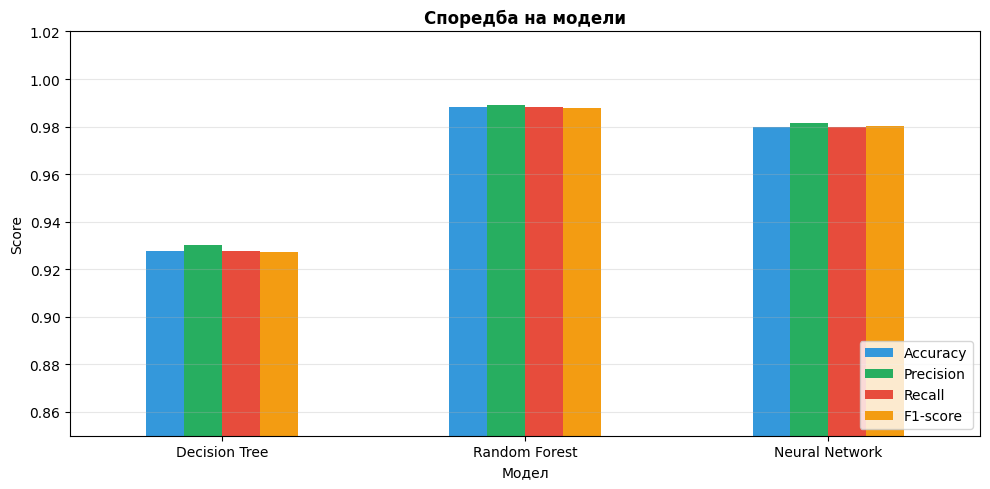

In [33]:
df_results.plot(kind='bar', figsize=(10, 5), color=['#3498db', '#27ae60', '#e74c3c', '#f39c12'])
plt.title('Споредба на модели', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.85, 1.02)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()